**Dataset:** Students' internship experience and employability (266 students).

Each student answered survey questions on a 5-point scale (1 = strongly disagree, 5 = strongly agree). The dataset gives an average score for each group of questions. I use two of them:

- **AVERAGE (EVS)**: how employable the student feels (used in Part 1)
- **AVERAGE (SIE)**: how good the student's internship experience was (used in Parts 2 to 6)

I chose this dataset because it is similar to the data I will collect for my project on AUI students' internships: both are student surveys about internship experience and career readiness, measured on rating scales.

**Codes used (from the dataset's Codebook):**
- School accreditation: 1 = A (excellent), 2 = B (good)
- Age: 1 = 16 years, 2 = 17 years, 3 = 18 years

In [99]:
# Import pandas and load the dataset
import pandas as pd
schools = pd.read_csv('internship_dataset_266_students.csv')


In [98]:
# Show the first 5 rows of the dataset
schools.head()


,Gender,Age,school status,school accreditation,SIE1,SIE2,SIE3,SIE4,SIE5,SIE6,...,EVS4,EVS5,EVS6,EVS7,EVS8,EVS9,EVS10,EVS11,EVS12,AVERAGE (EVS)
0,1,2,1,1,4,5,4,4,5,5,...,4,4,4,5,5,5,5,5,5,4.750000
1,1,3,1,1,5,4,4,4,4,4,...,4,3,5,4,4,2,4,3,2,3.500000
2,1,3,1,1,4,5,4,4,4,3,...,4,4,5,4,3,3,4,3,4,3.750000
3,1,3,1,1,4,4,4,4,4,3,...,4,4,4,4,4,4,4,4,4,4.000000
4,1,2,1,1,4,5,4,4,4,5,...,4,5,5,4,4,5,5,4,4,4.333333


In [100]:
# Import numpy and create two groups: A schools (1) and B schools (2)
import numpy as np
a_schools= schools[schools['school accreditation']== 1]
b_schools= schools[schools['school accreditation']==2]


In [48]:
# Calculate mean and median for A schools
print(np.mean(a_schools['AVERAGE (EVS)']))
print(np.median(a_schools['AVERAGE (EVS)']))

3.984732824427481
4.0


In [49]:
# Calculate mean and median for B schools
print(np.mean(b_schools['AVERAGE (EVS)']))
print(np.median(b_schools['AVERAGE (EVS)']))

3.956172839506173
4.083333333333333


In [101]:
# Subset A and B schools, group by accreditation, and compute mean and median of AVERAGE (EVS)
a_and_b = schools[(schools['school accreditation']== 1)|(schools['school accreditation']== 2)]
print(a_and_b.groupby('school accreditation')['AVERAGE (EVS)'].agg(['mean', 'median']))

                          mean    median
school accreditation                    
1                     3.984733  4.000000
2                     3.956173  4.083333


Part 1 – Interpretation:

The mean employability score is 3.98 for A schools and 3.96 for B schools. The difference is only 0.03 on a scale of 1 to 5, so students from A and B schools feel almost equally employable.

In B schools, the mean (3.96) is lower than the median (4.08). This happens because a few students gave very low scores, which pull the mean down. The median is not affected by these extreme values, because it only looks at the middle of the data.


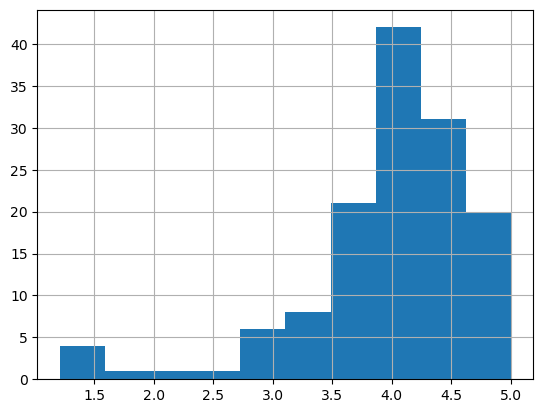

In [60]:
# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt
b_schools['AVERAGE (SIE)'].hist()
plt.show()

In [61]:
# Subset for school accreditation equals B
b_schools= schools[schools['school accreditation'] == 2] 
# Calculate mean and median of average (SIE) with  .agg()
print(b_schools['AVERAGE (SIE)'].agg(['mean', 'median']))

mean      3.982540
median    4.142857
Name: AVERAGE (SIE), dtype: float64


Part 2 – Interpretation

The histogram of the internship experience score (SIE) for B-school students is left-skewed. Most students scored between 3.5 and 5, but a few students gave very low scores (around 1.5 to 2.5), which creates a long tail on the left.

The mean (3.98) is lower than the median (4.14) because these few low scores pull the mean down. The median is not affected by extreme values.

Because the data is skewed, the median is the best measure to summarize the typical internship experience of B-school students.


In [68]:
# Calculate the quartiles of AVERAGE (SIE) for all students
quartiles = np.quantile(schools['AVERAGE (SIE)'],[0, 0.25, 0.5, 0.75, 1])
# Calculate the quintiles of AVERAGE (SIE) for all students
quintiles = np.quantile(schools['AVERAGE (SIE)'], [0, 0.2, 0.4, 0.6, 0.8, 1])
# Calculate the deciles of AVERAGE (SIE) for all students
deciles = np.quantile(schools['AVERAGE (SIE)'], np.linspace(0, 1, 11))

In [72]:
# Putting the quartiles on a table, with a label for each value (rounded to 2 decimals)
pd.DataFrame({
    'Position': ['Minimum ', ' Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Maximum' ],
    'SIE score': quartiles.round(2)
})



,Position,SIE score
0,Minimum,1.21
1,Q1 (25%),3.79
2,Median (50%),4.07
3,Q3 (75%),4.36
4,Maximum,5.00


In [73]:
# Putting the quintiles on a table, with a label for each value (rounded to 2 decimals)
pd.DataFrame({
    'Position': ['Minimum ', ' (20%)', ' (40%)', '(60%)','(80%)', 'Maximum' ],
    'SIE score': quintiles.round(2)
})


,Position,SIE score
0,Minimum,1.21
1,(20%),3.64
2,(40%),4.00
3,(60%),4.21
4,(80%),4.43
5,Maximum,5.00


In [75]:
# Putting the deciles on a table, with a label for each value (rounded to 2 decimals)
pd.DataFrame({
    'Position': ['Minimum ', ' (10%)', '(20%)', ' (30%)', '(40%)','(50%)','(60%)','(70%)','(80%)','(90%)','Maximum' ],
    'SIE score': deciles.round(2)
})

,Position,SIE score
0,Minimum,1.21
1,(10%),3.29
2,(20%),3.64
3,(30%),3.86
4,(40%),4.00
5,(50%),4.07
6,(60%),4.21
7,(70%),4.29
8,(80%),4.43
9,(90%),4.64


Part 3 – Interpretation

The lowest SIE score is 1.21 and the highest is 5.00. 25% of students scored below 3.79 (Q1), half scored below 4.07 (the median), and 75% scored below 4.36 (Q3).

The middle 50% of students scored between 3.79 and 4.36, which is a narrow range. This means most students had a similar and fairly positive internship experience.

The deciles show that the bottom 10% of students scored below 3.29, while the top 10% scored above 4.64. The minimum (1.21) is far below the other values, which shows that a few students had a very bad internship experience.

In [102]:
# Print variance and standard deviation of AVERAGE (SIE) for each age group
print(schools.groupby('Age')['AVERAGE (SIE)'].agg(['var','std']))

          var       std
Age                    
1    0.271811  0.521355
2    0.424302  0.651385
3    0.256559  0.506517


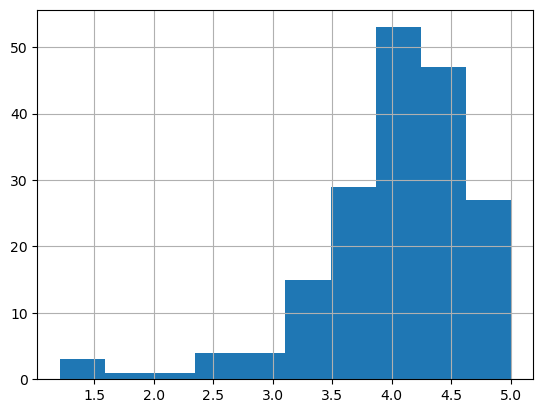

In [83]:
# Histogram of AVERAGE (SIE) for 17-year-old students
schools[schools['Age'] == 2]['AVERAGE (SIE)'].hist()
plt.show()

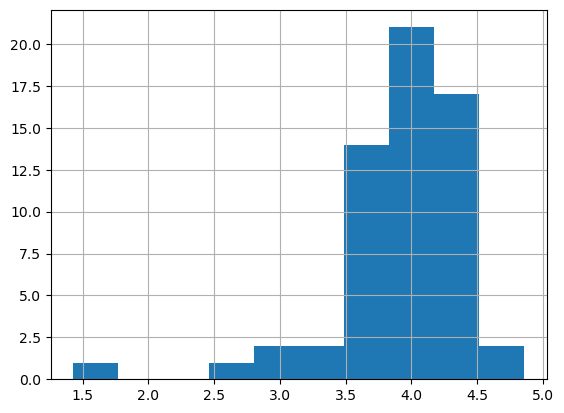

In [84]:
# Histogram of AVERAGE (SIE) for 18-year-old students
schools[schools['Age'] == 3]['AVERAGE (SIE)'].hist()
plt.show() 

Part 4 – Interpretation

17-year-old students have the biggest spread in their internship experience scores (standard deviation = 0.65). This means their experiences were more different from each other: some had very good internships and some had very bad ones.

18-year-old students are the most consistent (standard deviation = 0.51), followed closely by 16-year-olds (0.52). Their scores are closer to each other.

The histograms confirm this: the 17-year-olds' scores are spread from about 1.3 to 5, while most 18-year-olds' scores are grouped between 3.5 and 4.5.


In [103]:
# Compute the first and third quartiles and IQR of AVERAGE (SIE)
q1 = np.quantile(schools['AVERAGE (SIE)'], 0.25)
q3 = np.quantile(schools['AVERAGE (SIE)'], 0.75)
iqr = q3 - q1


In [86]:
# Calculate the lower and upper cutoffs for outliers
lower = q1 - 1.5 * iqr
upper = q3 + 1.5* iqr 

In [104]:
# Find the students whose SIE score is below the lower cutoff or above the upper cutoff
outliers = schools[(schools['AVERAGE (SIE)']< lower)|(schools['AVERAGE (SIE)']> upper)]
print(outliers['AVERAGE (SIE)'])

24     2.642857
36     2.928571
39     2.714286
84     2.714286
85     2.714286
123    2.928571
162    2.000000
179    2.785714
192    2.785714
197    1.500000
201    1.428571
203    1.928571
210    2.785714
213    1.500000
223    1.214286
261    2.214286
Name: AVERAGE (SIE), dtype: float64


Using the IQR rule, any SIE score below 2.93 is an outlier. 16 students are outliers, and all of them have unusually low scores (between 1.21 and 2.93), which means they rated their internship experience much worse than the other students.

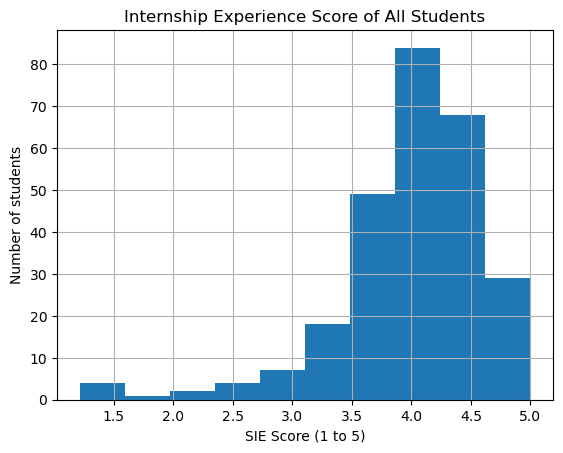

In [93]:
#HISTOGRAM plot of AVERAGE (SIE) for all students 
schools['AVERAGE (SIE)'].hist()
plt.title('Internship Experience Score of All Students')
plt.xlabel('SIE Score (1 to 5)')
plt.ylabel('Number of students')
plt.show()

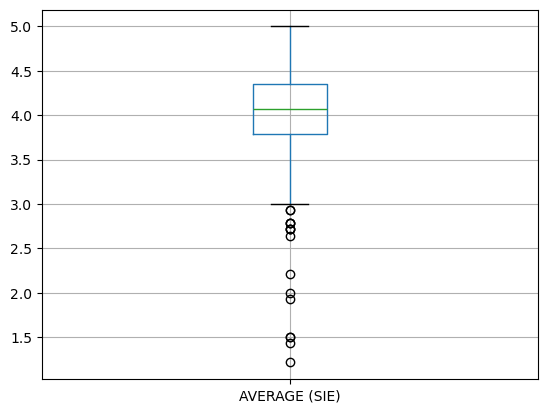

In [94]:
# Box plot of AVERAGE (SIE) for all students 
schools.boxplot(column = 'AVERAGE (SIE)')
plt.show()

Part 6 – Interpretation

The histogram and the box plot both show that most students rated their internship experience positively: the middle 50% scored between 3.79 and 4.36, with a median of 4.07. The distribution is left-skewed, with a few students giving very low scores. These students appear as outliers (circles) below the lower whisker of the box plot, which matches the 16 outliers found in Part 5.
